# Imports

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# noinspection PyPackageRequirements
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import normaltest, anderson
from scipy.stats import shapiro
from scipy.stats import spearmanr
import os
import shutil
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from scipy.stats import levene

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from category_encoders.leave_one_out import LeaveOneOutEncoder

# Load datasets

In [2]:
# Load datasets
df1 = pd.read_csv("observations.tsv", sep='\t')
df2 = pd.read_csv("patients.tsv", sep='\t')
df3 = pd.read_csv("stations.tsv", sep='\t')

In [3]:
df1.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude']

In [4]:
df2.columns.tolist()

['address',
 'job',
 'company',
 'blood_group',
 'ssn',
 'station_ID',
 'current_latitude',
 'current_longitude']

In [5]:
df3.columns.tolist()

['longitude', 'latitude', 'code', 'station', 'location']

In [6]:
result = df2.groupby('station_ID')['blood_group'].value_counts()
print(result)

station_ID  blood_group
0           AB+            1
1           A-             2
            A+             1
            AB+            1
            AB-            1
                          ..
804         AB+            1
            B-             1
805         A-             1
            B-             1
            O+             1
Name: count, Length: 1772, dtype: int64


We are going to join observations with stations because:
    - both dataset contain latitude + longtitude and we know that it can be mapped one to another
    - station, code, location may represent different equipment, staff, these may influence the measuremtns

We are not merging df2 with observations because:
    - There is no common identifier
    - The only possible link is bet stations and it would bring errors
    - Label noise if we incorrectly link patient with observation
    - Aggregating patient attributes per station is not useful because attributes blood_group, job, company, address are individual specific, not station-level

# Merging df1 with df3

In [7]:
keys = ['longitude', 'latitude']
df = pd.merge(df1, df3, on=keys, how='inner')

In [8]:
df.shape

(12072, 26)

Did not lose any records, attributes added only.
Our target is oximetry.
We have numeric features and categorical features.

In [9]:
df.columns.tolist()

['SPO2',
 'HR',
 'PI',
 'RR',
 'ETCO2',
 'FIO2',
 'PRV',
 'BP',
 'ST',
 'MAI',
 'PVI',
 'Hb level',
 'SV',
 'CO',
 'Blood Flow Index',
 'PPG waveform features',
 'Signal Quality Index',
 'Respiratory effort',
 'O₂ extraction ratio',
 'SNR',
 'oximetry',
 'latitude',
 'longitude',
 'code',
 'station',
 'location']

In [10]:
df['location'].nunique()

140

In [11]:
df['code'].nunique()

107

In [12]:
df['station'].nunique()

552

Location is high-cardinality categorical - one hot encoding would increase dimensionality and it would hurt our model, no meaningful geographical location, we already have latitude and longitude

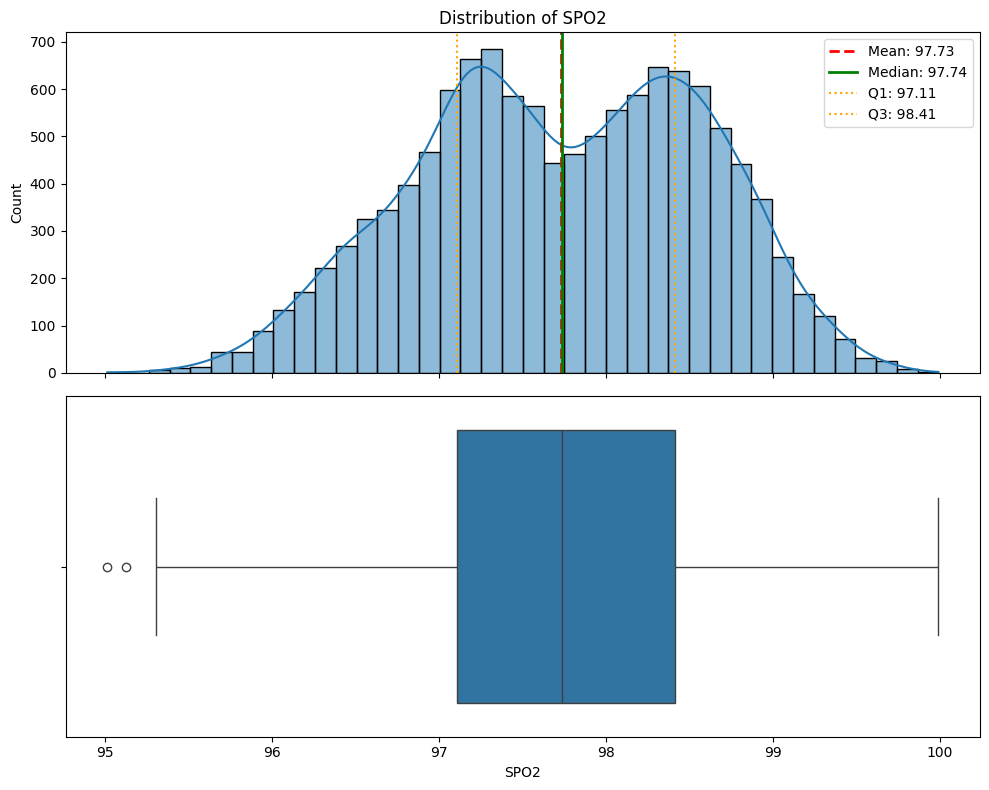


--- SPO2 ---
Probably not normal
------------------------------------------------------------


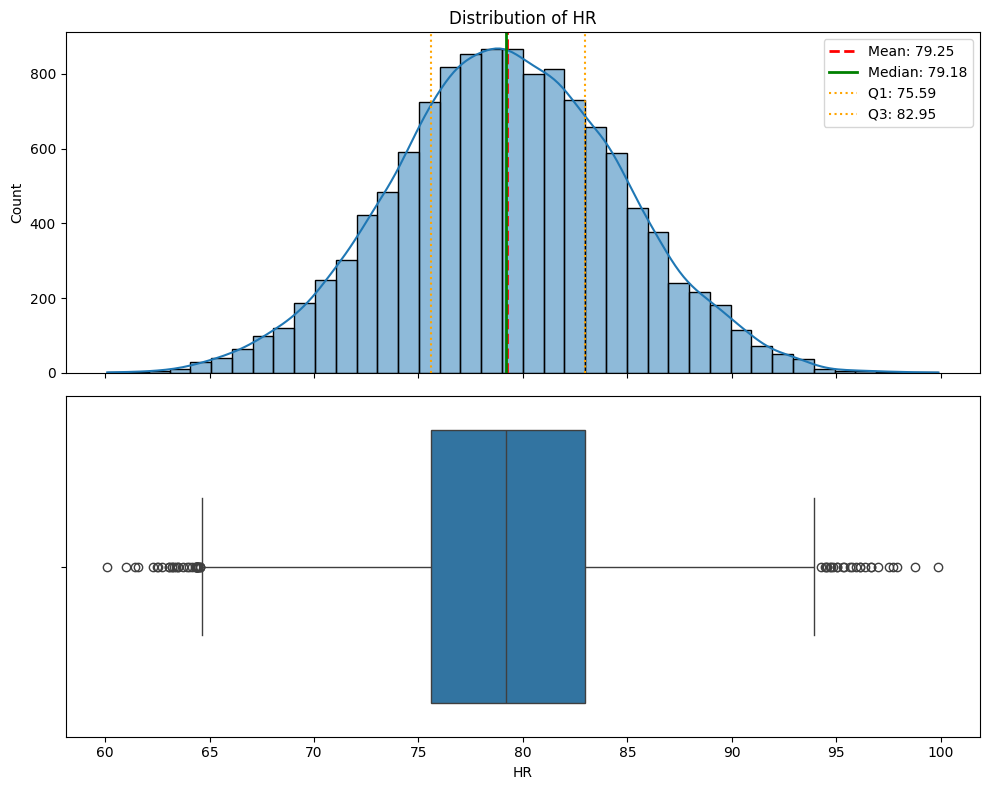


--- HR ---
Probably normal
------------------------------------------------------------


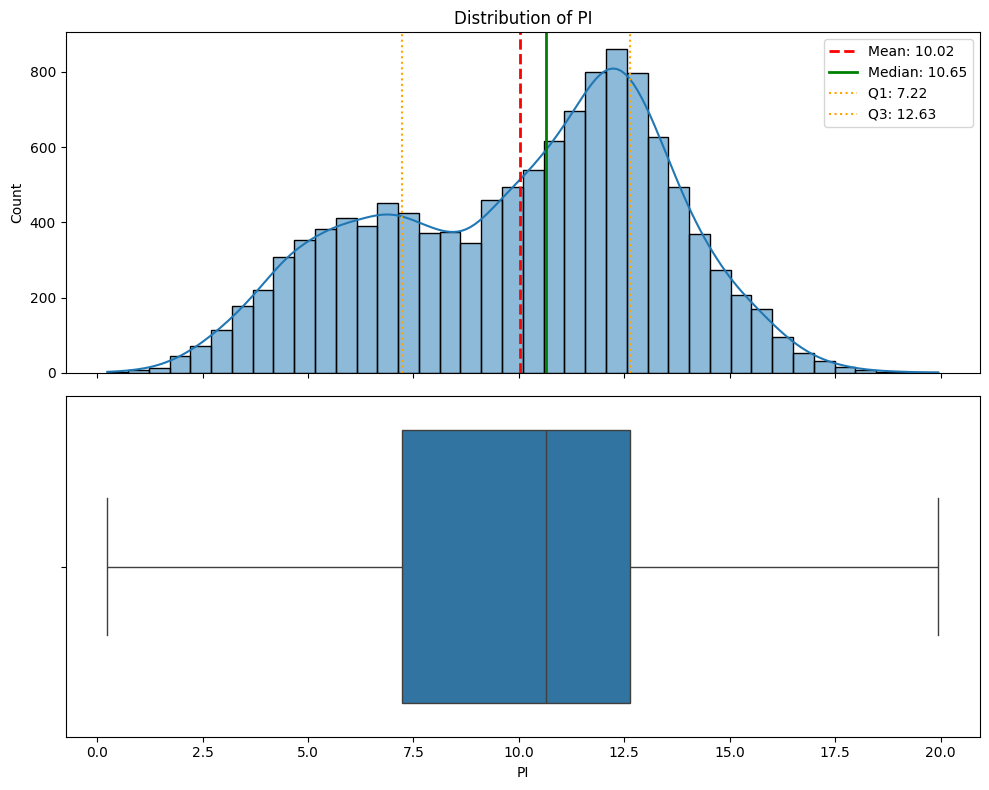


--- PI ---
Probably not normal
------------------------------------------------------------


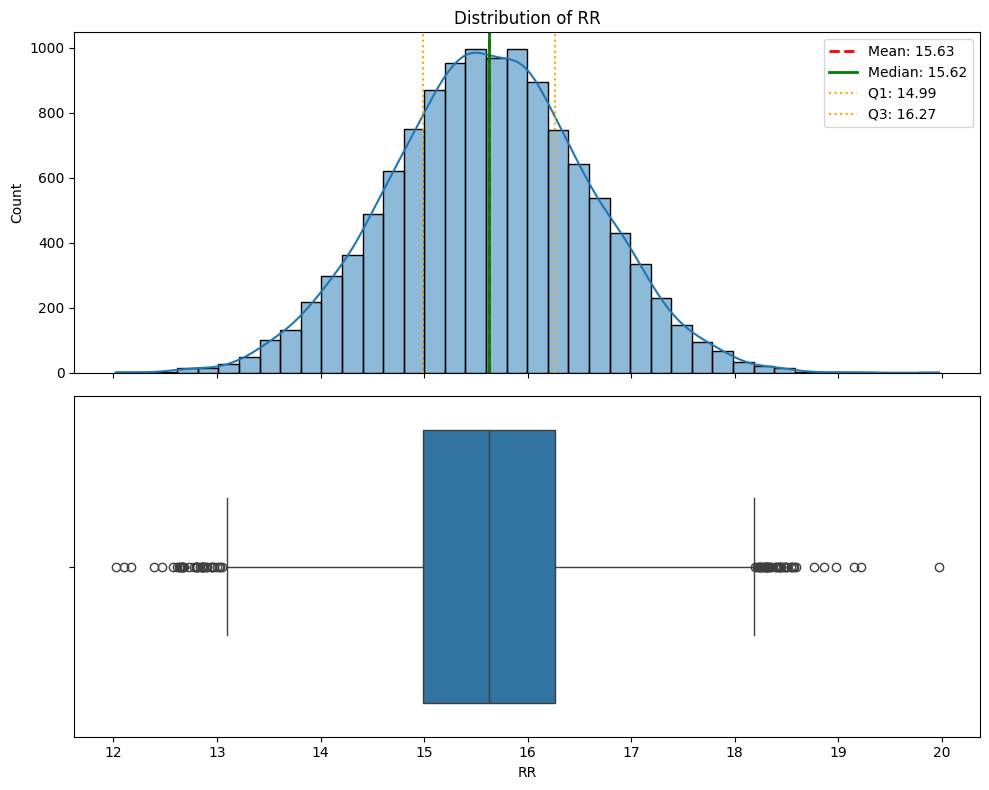


--- RR ---
Probably normal
------------------------------------------------------------


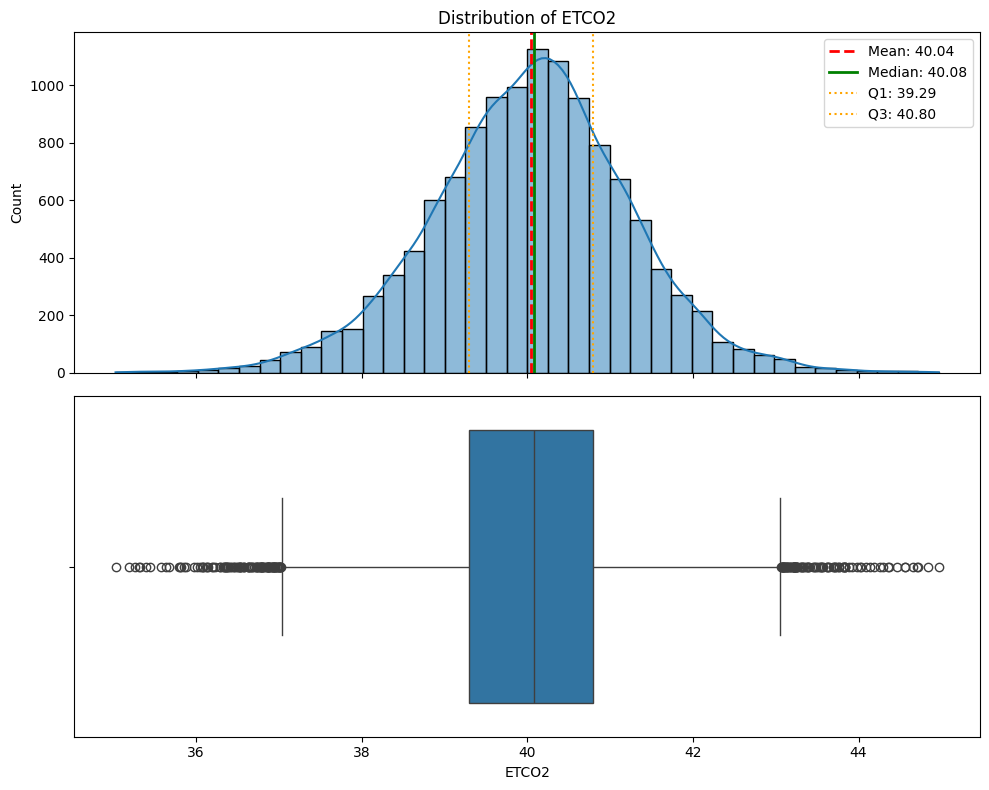


--- ETCO2 ---
Probably not normal
------------------------------------------------------------


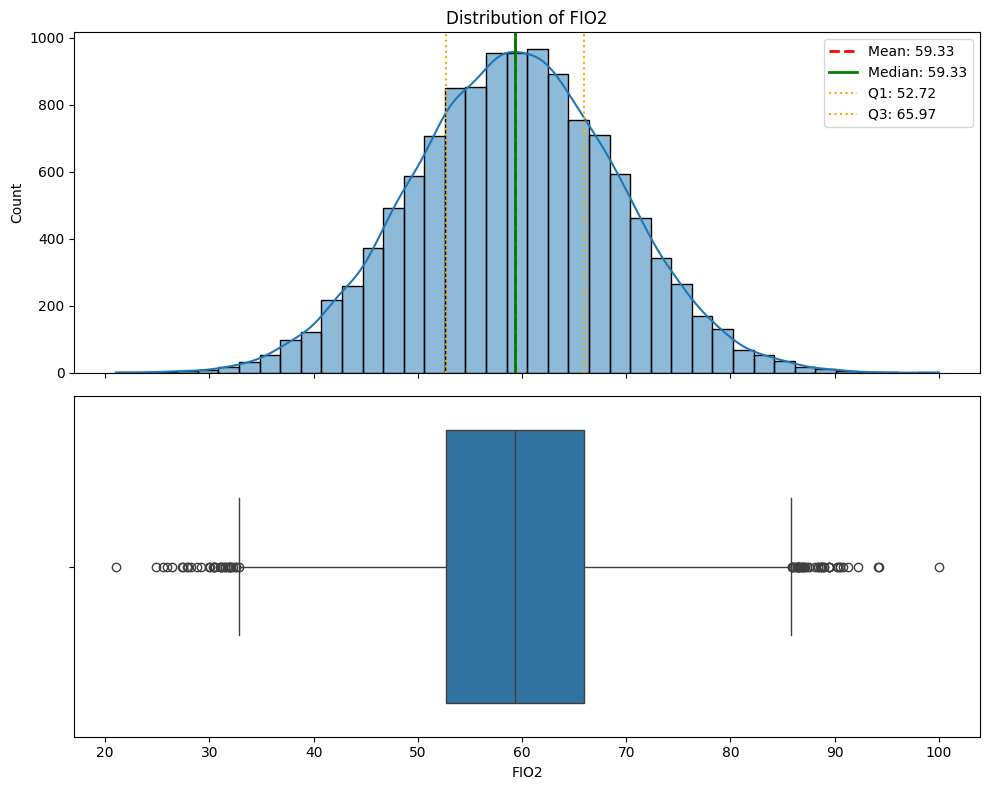


--- FIO2 ---
Probably normal
------------------------------------------------------------


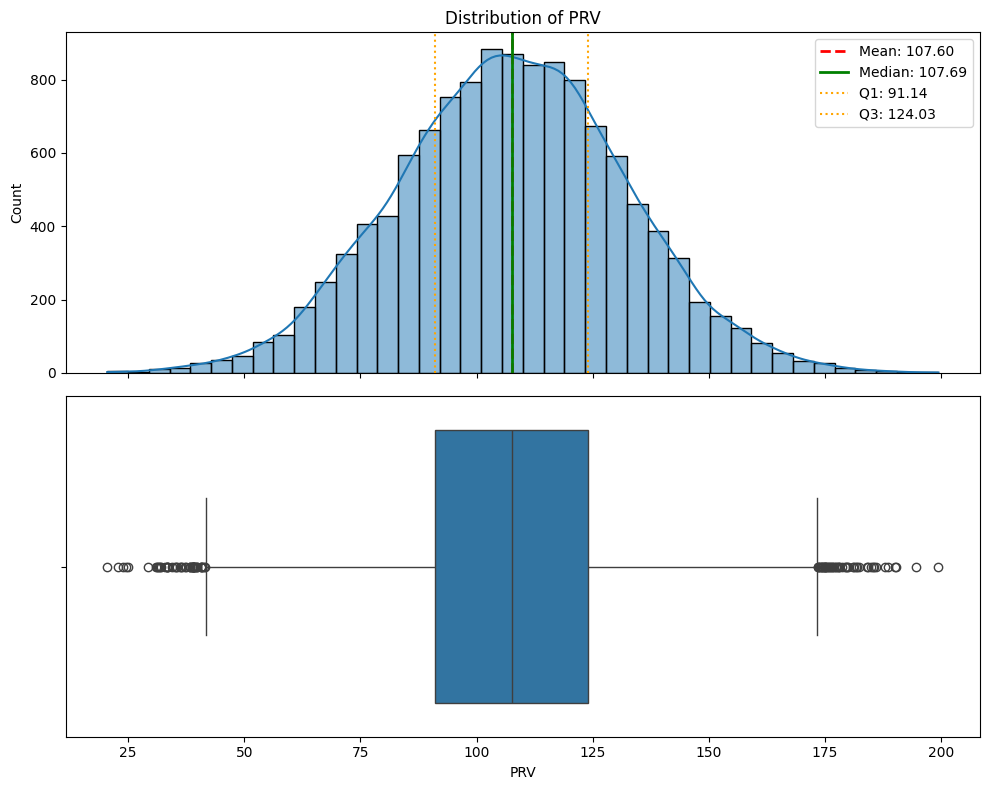


--- PRV ---
Probably normal
------------------------------------------------------------


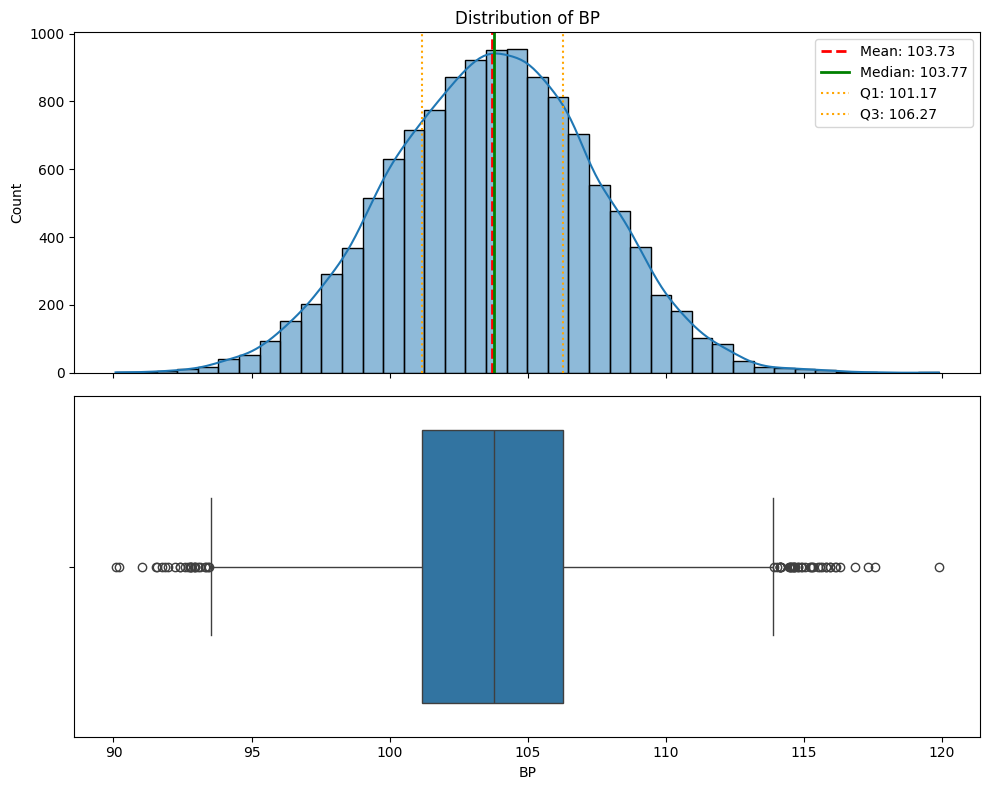


--- BP ---
Probably normal
------------------------------------------------------------


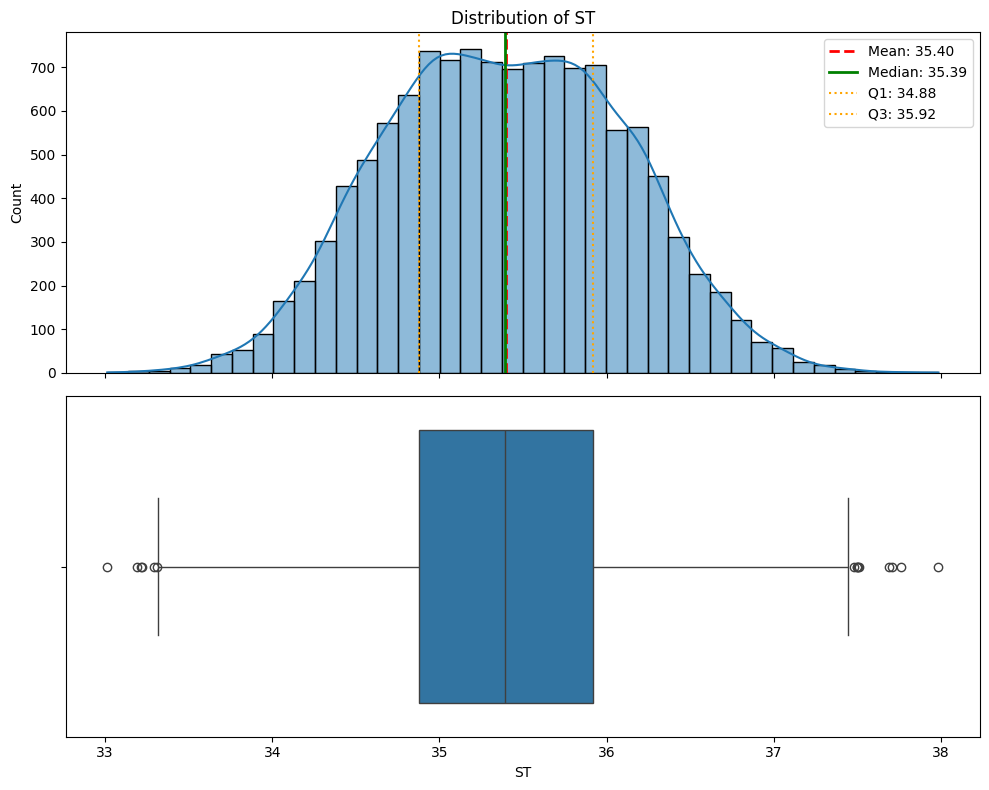


--- ST ---
Probably not normal
------------------------------------------------------------


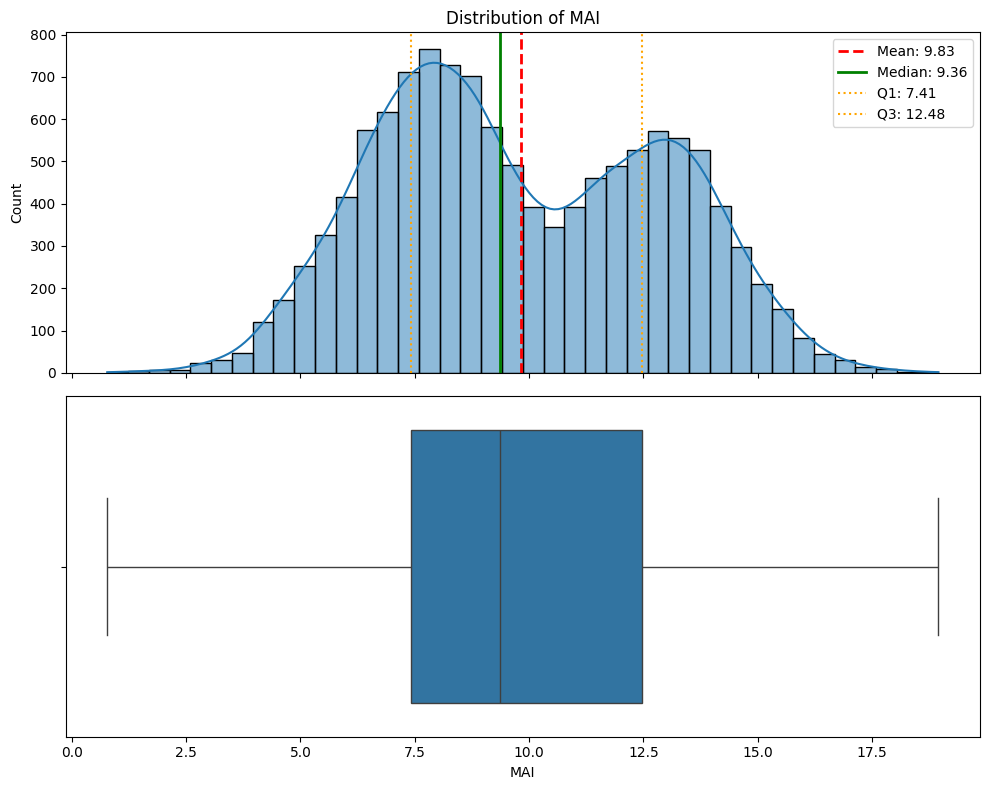


--- MAI ---
Probably not normal
------------------------------------------------------------


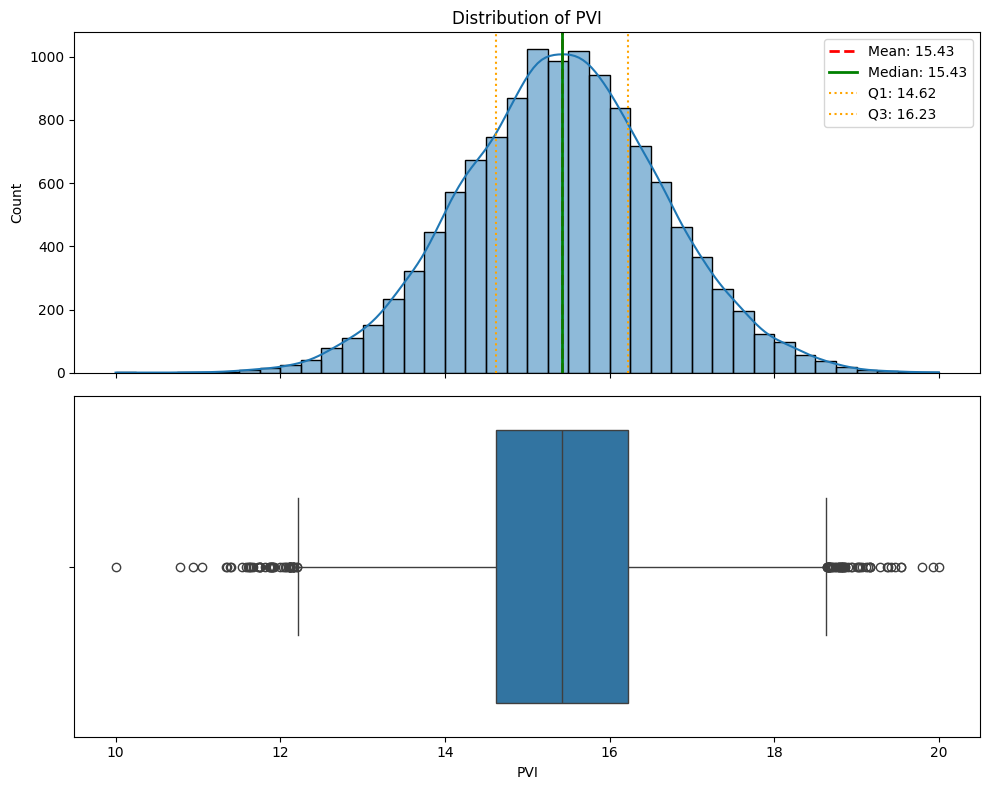


--- PVI ---
Probably normal
------------------------------------------------------------


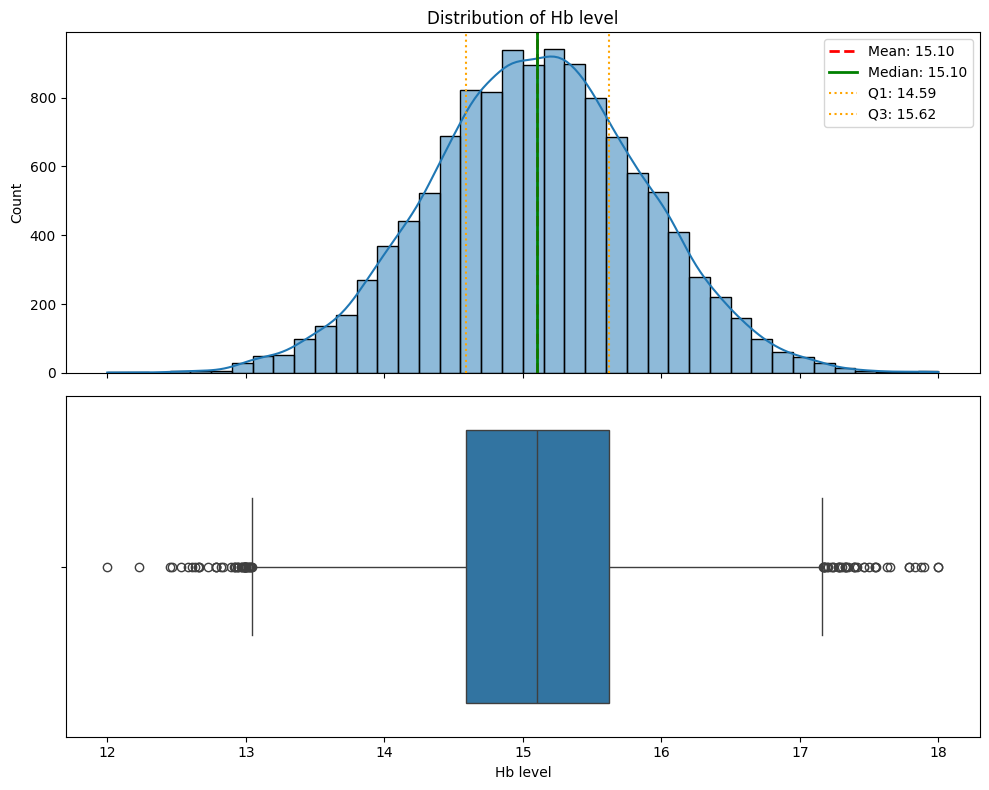


--- Hb level ---
Probably normal
------------------------------------------------------------


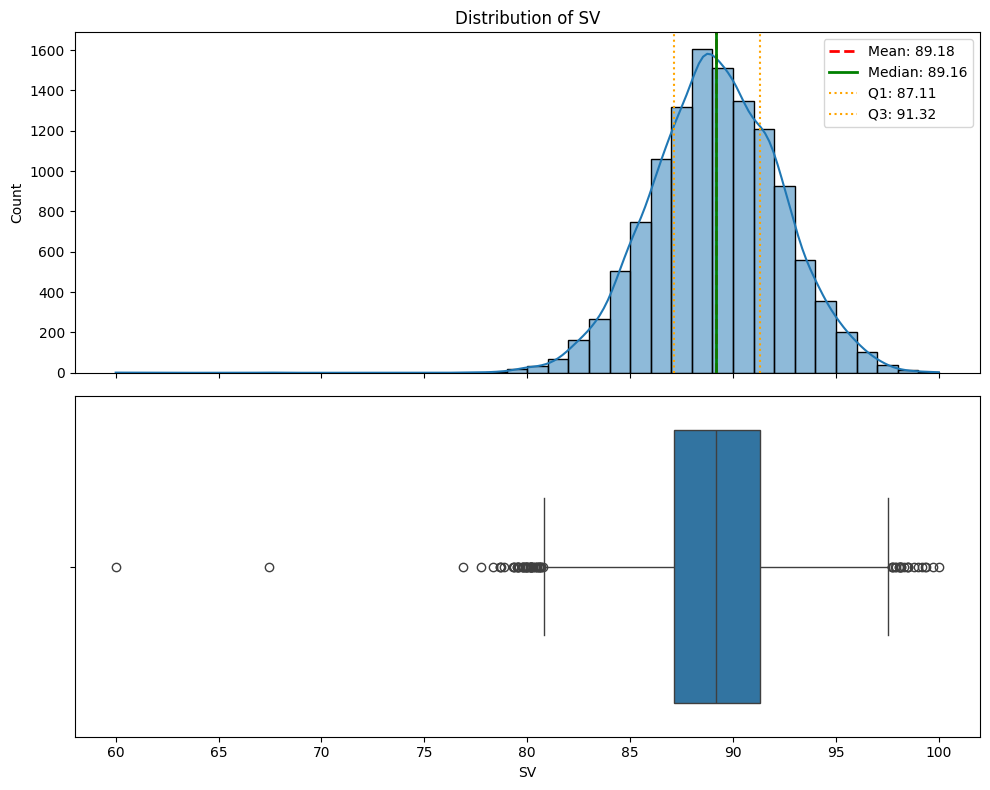


--- SV ---
Probably not normal
------------------------------------------------------------


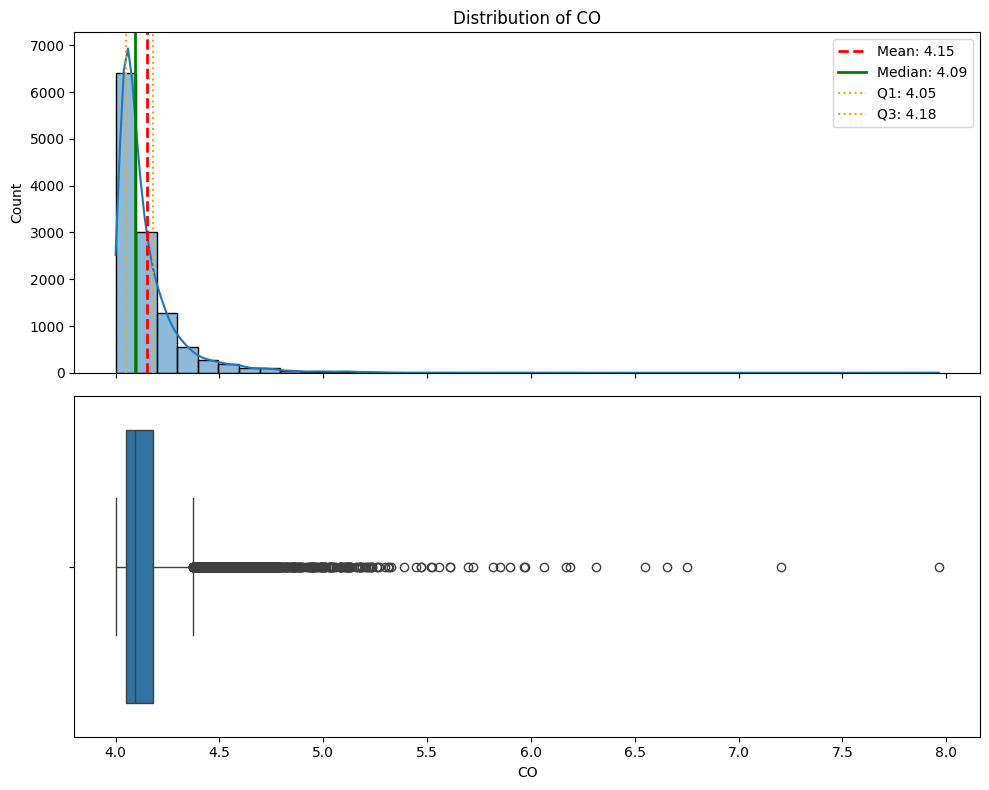


--- CO ---
Probably not normal
------------------------------------------------------------


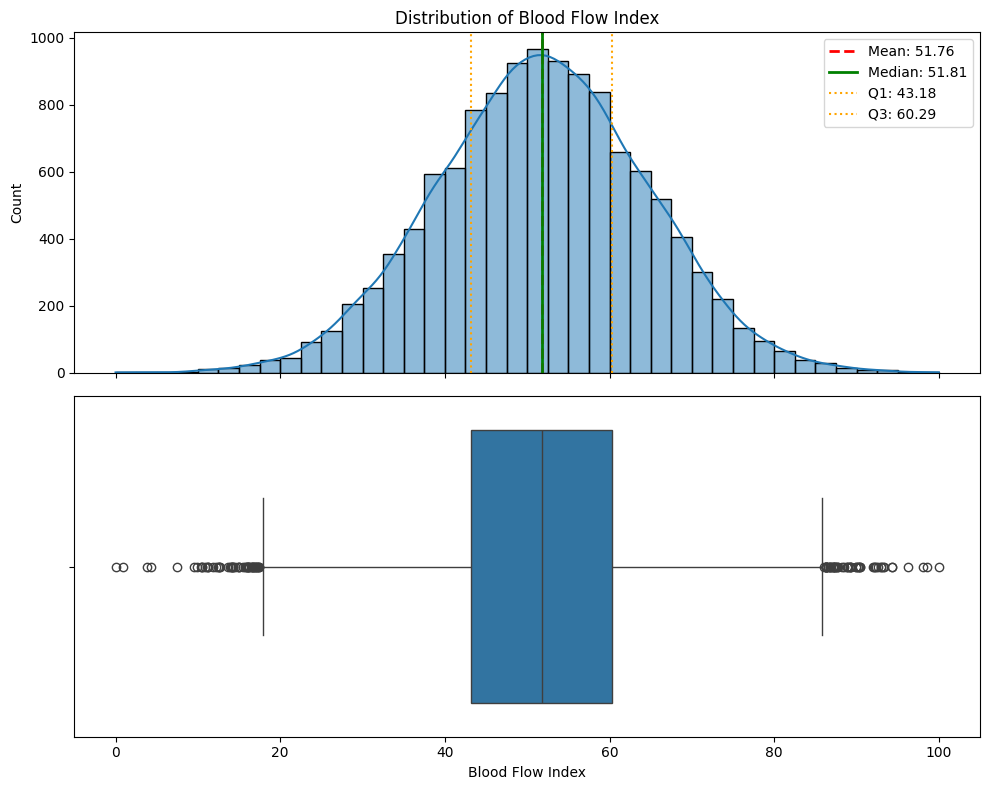


--- Blood Flow Index ---
Probably normal
------------------------------------------------------------


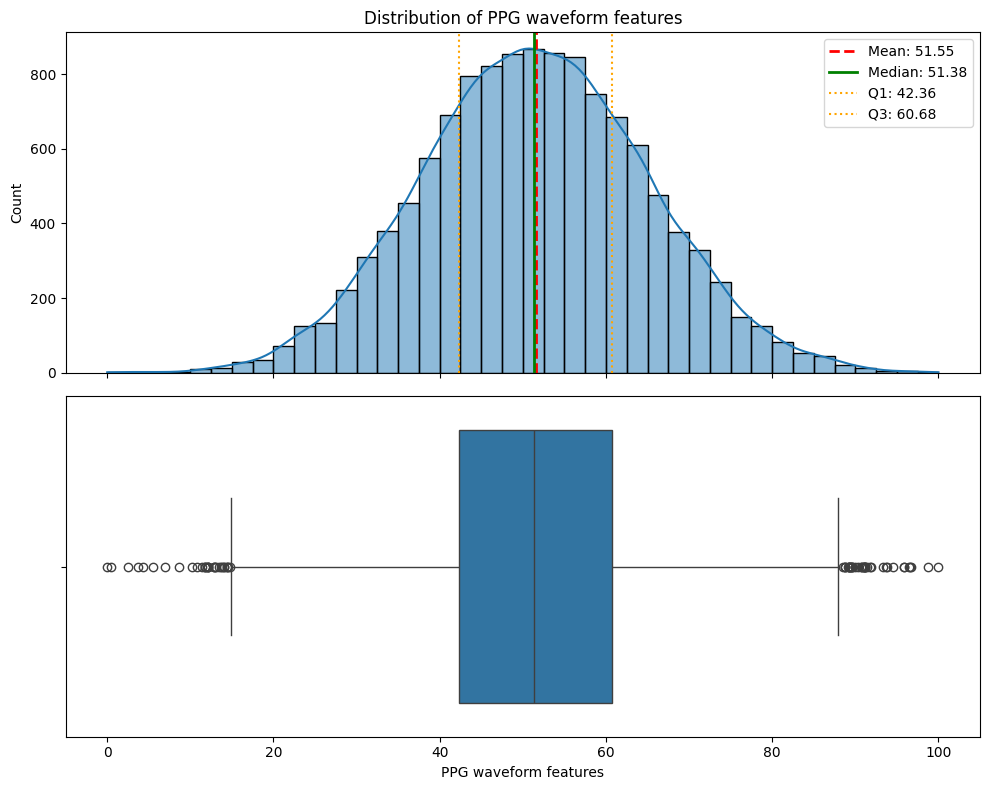


--- PPG waveform features ---
Probably normal
------------------------------------------------------------


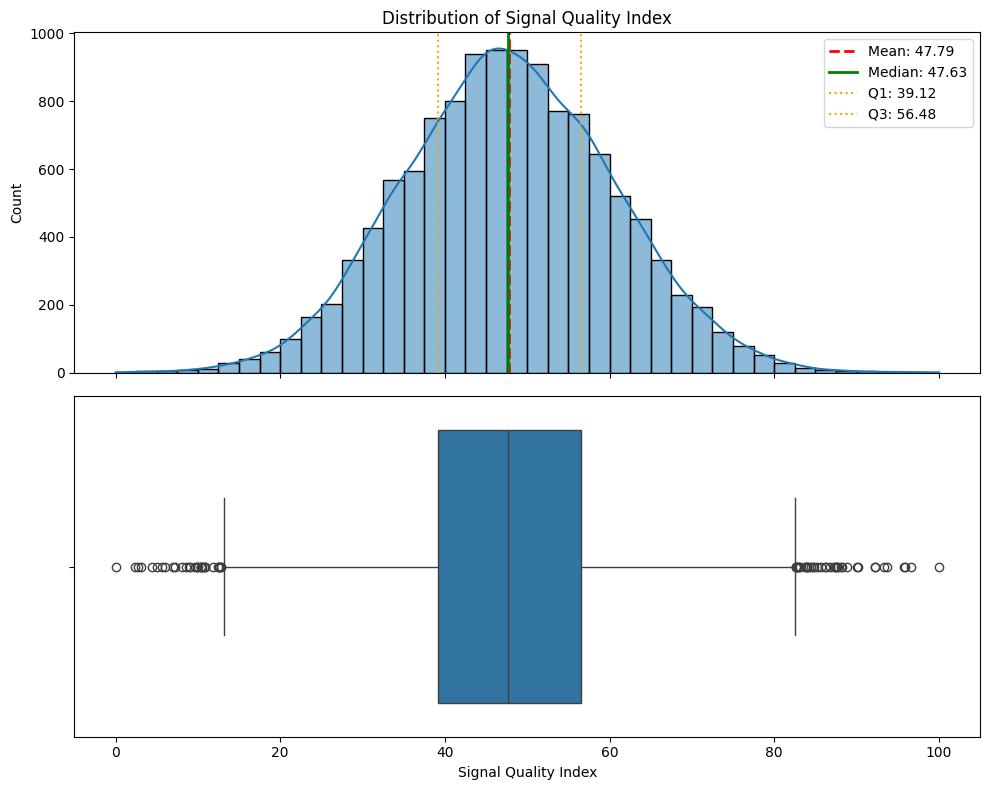


--- Signal Quality Index ---
Probably normal
------------------------------------------------------------


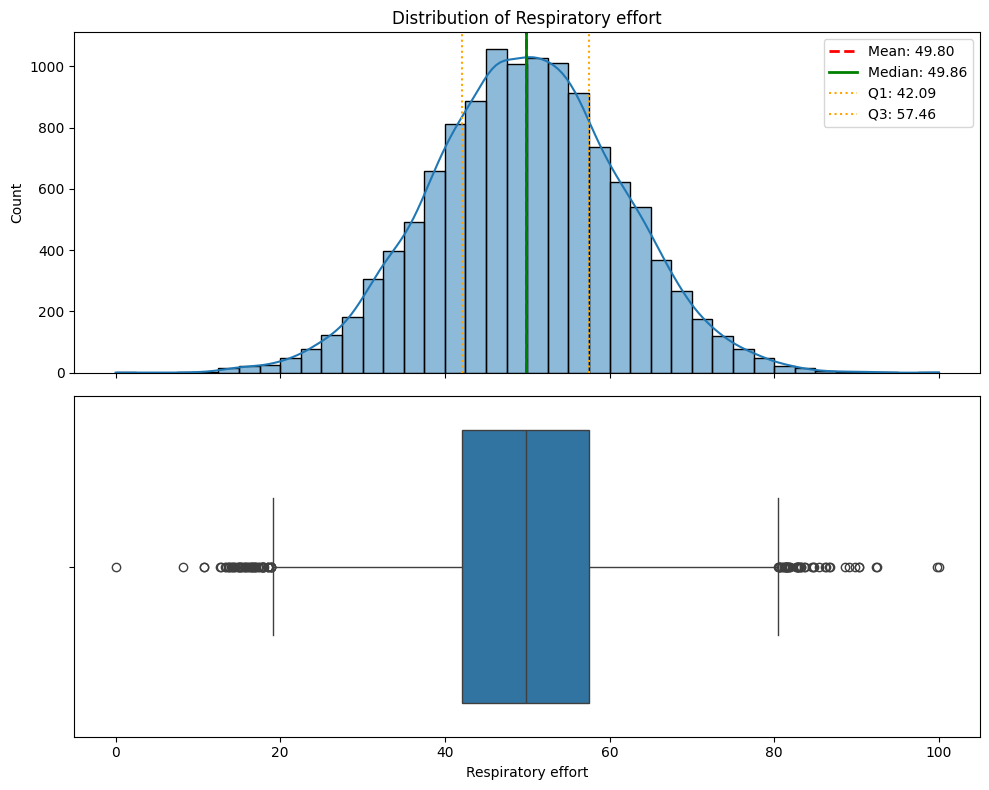


--- Respiratory effort ---
Probably normal
------------------------------------------------------------


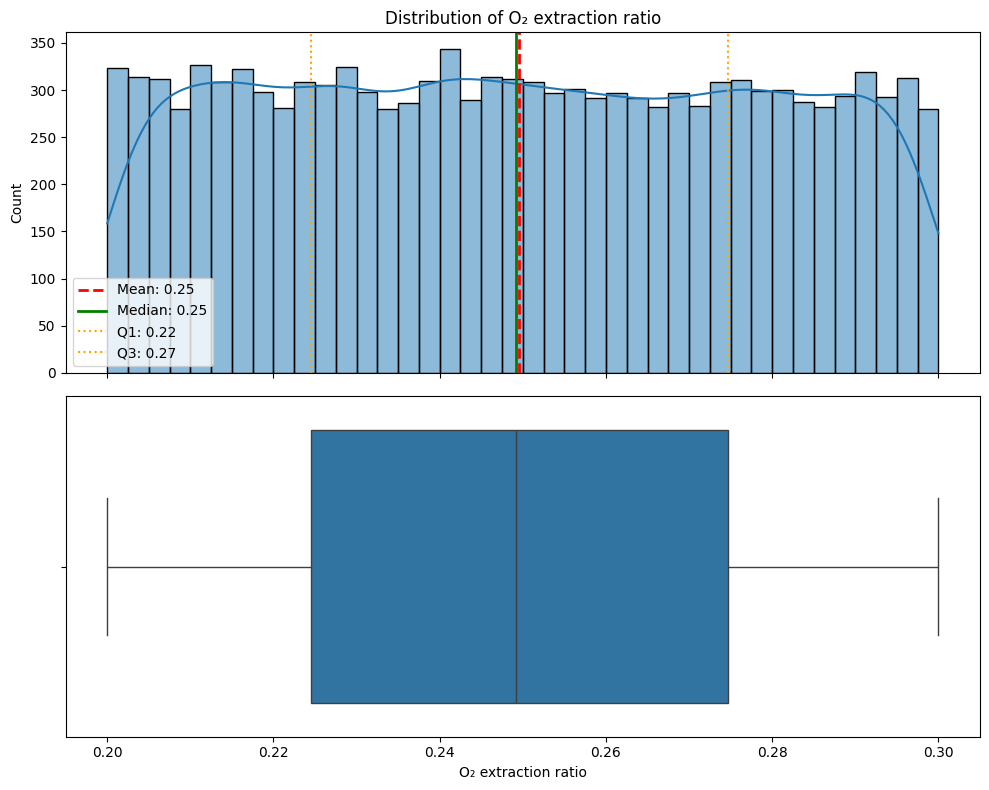


--- O₂ extraction ratio ---
Probably not normal
------------------------------------------------------------


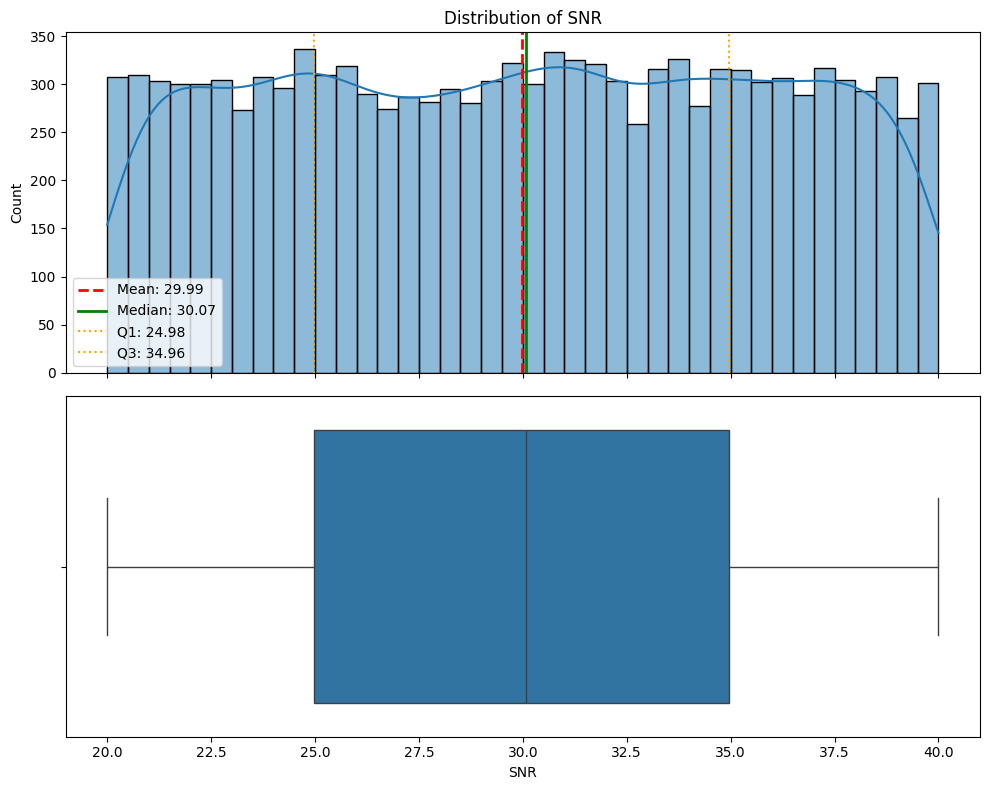


--- SNR ---
Probably not normal
------------------------------------------------------------


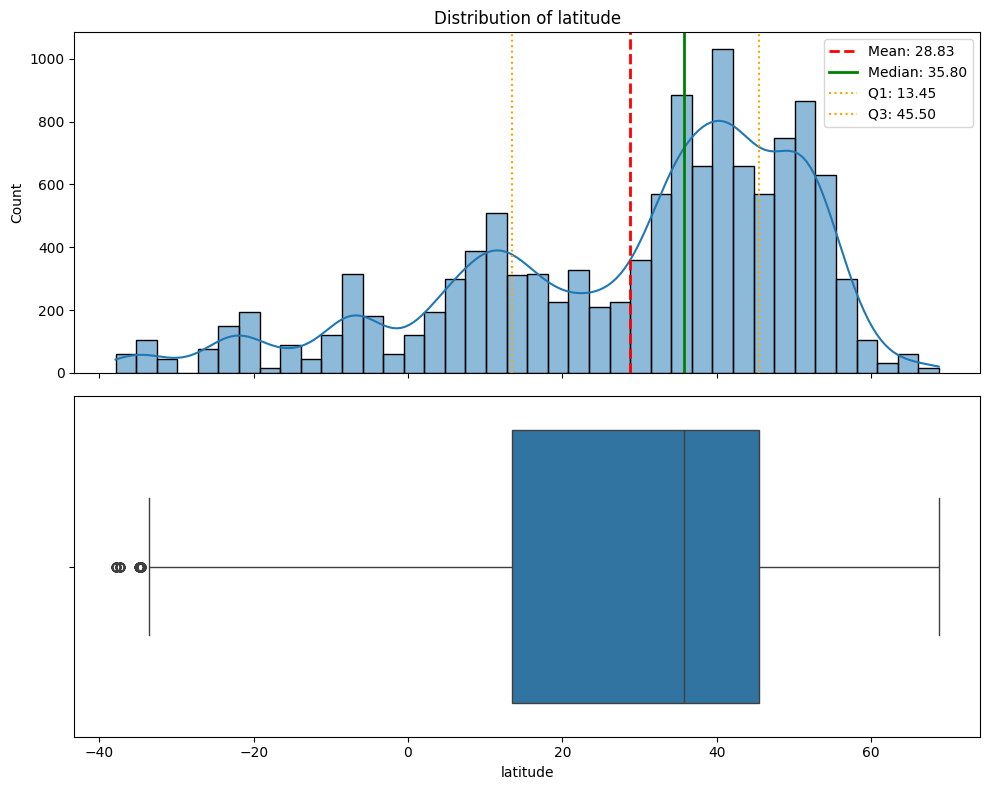


--- latitude ---
Probably not normal
------------------------------------------------------------


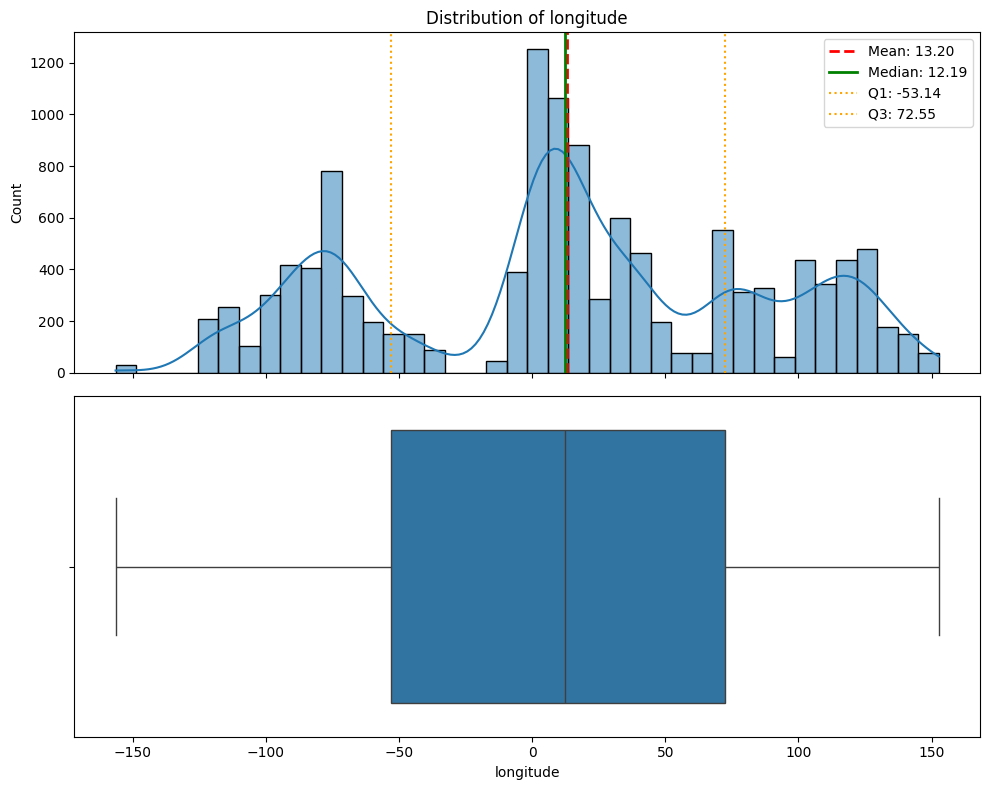


--- longitude ---
Probably not normal
------------------------------------------------------------


In [50]:
numeric_cols = [
    'SPO2',
    'HR',
    'PI',
    'RR',
    'ETCO2',
    'FIO2',
    'PRV',
    'BP',
    'ST',
    'MAI',
    'PVI',
    'Hb level',
    'SV',
    'CO',
    'Blood Flow Index',
    'PPG waveform features',
    'Signal Quality Index',
    'Respiratory effort',
    'O₂ extraction ratio',
    'SNR',
    'latitude','longitude']
    

for col in numeric_cols:
    # Create figure with 2 subplots stacked vertically
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Top plot: Histogram with KDE
    sns.histplot(df[col], bins=40, kde=True, ax=ax1)
    
    # Calculate statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    # Add vertical lines for mean, median, Q1, Q3 on histogram
    ax1.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax1.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
    ax1.axvline(q1, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q1:.2f}')
    ax1.axvline(q3, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q3:.2f}')
    ax1.set_title(f'Distribution of {col}')
    ax1.legend()
    
    # Bottom plot: Boxplot (horizontal)
    sns.boxplot(x=df[col], ax=ax2)
    ax2.set_xlabel(col)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n--- {col} ---")
    
    # Normality test
    stat, p = normaltest(df[col].dropna())
    if p > 0.05:
        print("Probably normal")
    else:
        print("Probably not normal")
    print("-" * 60)

In [58]:
TARGET = 'oximetry'

STANDARD_NUM = [
    'HR','RR','FIO2','PRV','BP','PVI','Hb level',
    'Blood Flow Index','PPG waveform features',
    'Signal Quality Index','Respiratory effort',
    'O₂ extraction ratio','SNR'
]

ROBUST_NUM = [
    'SPO2','PI','ETCO2','ST','MAI','SV','latitude','longitude'
]

POWER_NUM = ['CO']

LOW_CARD_CAT_COLS = [
    'code'        # 107 levels
]

HIGH_CARD_CAT_COLS = [
    'station'     # 552 levels
]

DROP_COLS = [
    'location'
]

In [59]:
df['code'].isnull().sum()

np.int64(0)

From phase 1 we know that one station has no code, we are going to fill these 15 observations with most frequent code in this dataset. which might have changed because we merged it with observations and that could transfer another code as most frequent if that region has many observations..

In [60]:
most_frequent_value = df['code'].mode().iloc[0]
print(most_frequent_value)

US


US is the most frequent one

In [61]:
df['code'] = df['code'].fillna(most_frequent_value)

In [62]:
df['code'].isnull().sum()

np.int64(0)

# Now we divide data into train and test

In [57]:
X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {X_train.shape}, Test size: {X_test.shape}")

Training size: (9657, 24), Test size: (2415, 24)


# PIPELINES FOR EACH COLUMN GROUP

In [65]:
standard_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

robust_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

power_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),  # handles zeros/negatives
    ("scaler", StandardScaler())
])

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("leaveoneout", LeaveOneOutEncoder())
])

# FULL COLUMN TRANSFORMER

In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num_standard", standard_numeric_pipeline, STANDARD_NUM),
        ("num_robust", robust_numeric_pipeline, ROBUST_NUM),
        ("num_power", power_numeric_pipeline, POWER_NUM),
        ("lowcat", low_card_pipeline, LOW_CARD_CAT_COLS),
        ("highcat", high_card_pipeline, HIGH_CARD_CAT_COLS),
    ],
    remainder="drop"
)

# FIT TRANSFORM ON TRAINING DATA

In [67]:
preprocessor.fit(X_train, y_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [68]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)
print("Processed type:", type(X_train_processed))

Processed X_train shape: (9657, 130)
Processed X_test shape: (2415, 130)
Processed type: <class 'scipy.sparse._csr.csr_matrix'>


We designed the preprocessing pipeline according to the characteristics of the data.

We have splitted data before preprocessing in 80:20 train:test. We dropped one attribute, we have numerical attributes, and low and high cardinality categorical data.

We used three techniques for scaling. Based on the distribution inspection. We used StandardScaler for normal distributions. And robust scaler which is used for non normal bimodal and skewed data and lastly powerTransformer 


no to je zle treba 2 scaling tcghniky dve trannsformerove